# Iris Task 1 - Classification Project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

#### Load data from iris.data file 

In [3]:
data_path = "/Users/artaosmani/TTT4275-classification-project/Data/Iris_TTT4275/iris.data"
col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df = pd.read_csv(data_path, header=None, names=col_names)

# label classes from 0-2
label_map = {
    'Iris-setosa': 0,
    'Iris-versicolor': 1,
    'Iris-virginica': 2
}
df['label'] = df['class'].map(label_map)
print("First 5 rows with new coulumn named label:")
print(df.head())

First 5 rows with new coulumn named label:
   sepal_length  sepal_width  petal_length  petal_width        class  label
0           5.1          3.5           1.4          0.2  Iris-setosa      0
1           4.9          3.0           1.4          0.2  Iris-setosa      0
2           4.7          3.2           1.3          0.2  Iris-setosa      0
3           4.6          3.1           1.5          0.2  Iris-setosa      0
4           5.0          3.6           1.4          0.2  Iris-setosa      0



##### a) Use first 30 samples for training, last 20 for testing 


In [4]:
df_l = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'label']]

# Function to split the data -> spliting iris.data in 3 instead of opening 3 separate files
def splitData(df, n_train, n_test):
    train_df = pd.concat([df[df['label'] == i].iloc[:n_train] for i in range(3)])
    test_df = pd.concat([df[df['label'] == i].iloc[-n_test:] for i in range(3)])
    
    X_train = train_df.iloc[:, :-1].values #making a matrix with all rows and all columns exept label
    y_train = train_df['label'].values
    X_test = test_df.iloc[:, :-1].values
    y_test = test_df['label'].values
    
    return X_train, y_train, X_test, y_test

X_train, y_train, X_test, y_test = splitData(df_l, 30, 20)
print("X_train:", X_train.shape, "| Eksempel:", X_train[0])

X_train: (90, 4) | Eksempel: [5.1 3.5 1.4 0.2]


#### self defined linear clasifier (MSE + Gradient decent)

Train linear classifier using gradient descent on MSE loss.

X: input shape (n_samples, n_features)

y: class labels (n_samples,)

Returns: weight matrix W of shape (num_classes, n_features+1)
    

Sigmoid function from chapter 3.2: 

$$
g_{ik} = \text{sigmoid}(z_{ik}) = \frac{1}{1 + e^{-z_{ik}}}
$$



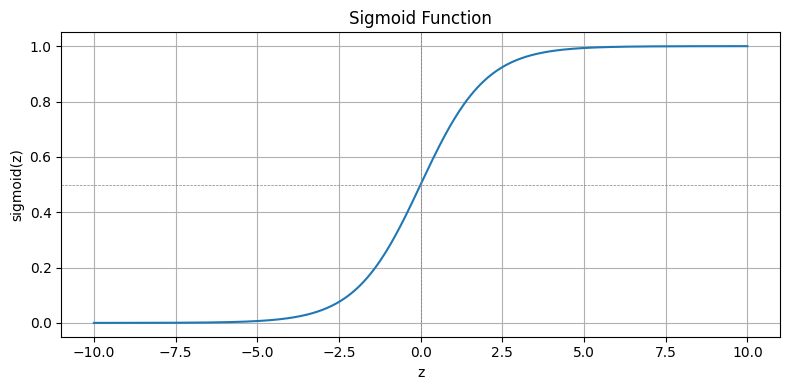

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 400)
sigmoid_values = sigmoid(z_values)

# Plot the sigmoid function
plt.figure(figsize=(8, 4))
plt.plot(z_values, sigmoid_values)
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.grid(True)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

One hot encode:

In [6]:
def one_hot_encode(y, num_classes):
    return np.eye(num_classes)[y]

Computing MSE from equation (19):

$$
\text{MSE} = \frac{1}{2} \sum_{k=1}^{N} (g_k - t_k)^T (g_k - t_k)
$$


In [7]:
def mse(g, t):
    return 0.5 * np.mean(np.sum((g - t) ** 2, axis=1)) 

Model training: Trains a linear classifier using MSE and sigmoid, according to Equations (19)–(23).


| Code                                 | Matches equations                     |
|--------------------------------------|----------------------------------------|
| `Z = X_bias @ W.T`                   | \( z_k = W x_k \), Eq. 20              |
| `G = sigmoid(Z)`                     | \( g_k = \sigma(z_k) \), Eq. 20        |
| `loss = mse(G, T)`                   | MSE from Eq. 19                        |
| `dG = (G - T) * G * (1 - G)`         | Gradient components from Eq. 22        |
| `gradient = dG.T @ X_bias / S`       | Full \( \nabla_W \text{MSE} \), Eq. 22 |
| `W = W - alpha * gradient`           | Update rule from Eq. 23                |
| `one_hot_encode(y, C)`              | Vectorial target format (needed for Eq. 19) |


In [8]:
def train_linear_classifier(X, Y, alpha=0.1, iterations=1000, threshold=1e-5):
    S, F = X.shape # S = numbers samples, F= number of features
    C = 3 #Numbers of classes
    
    ones = np.ones((S, 1))
    X_bias = np.hstack((X, ones))  
    F += 1                         

    T = one_hot_encode(Y, C)       

    W = np.random.randn(C, F) * 0.01  
    mse_values = []
   
    for i in range(iterations):  # Gradient descent loop
        Z = X_bias @ W.T             
        G = sigmoid(Z)               
        loss = mse(G, T) 
        mse_values.append(loss)           

        if loss < threshold:
            print("Converged at iteration", i, "with loss =", loss)
            break

        
        dG = (G - T) * G * (1 - G) #computing gradient      
        gradient = dG.T @ X_bias / S         
        W = W - alpha * gradient

    plt.figure(figsize=(8, 4))
    plt.plot(mse_values, label="MSE")
    plt.title("MSE vs. Iterations")
    plt.xlabel("Iteration")
    plt.ylabel("MSE Loss")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return W


def predict(X, W):
    X_bias = np.hstack((X, np.ones((X.shape[0], 1))))
    G = sigmoid(X_bias @ W.T)
    return np.argmax(G, axis=1)

c) Creating confusion matrix

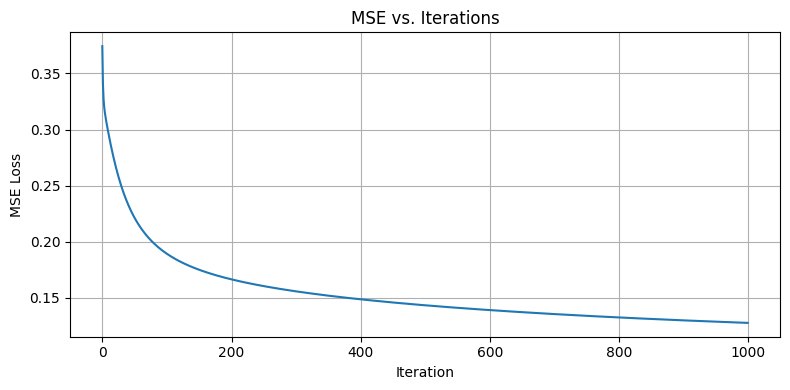

Confusion matrix (train):
[[30  0  0]
 [ 0 23  7]
 [ 0  0 30]]

Confusion matrix (test):
[[20  0  0]
 [ 0 16  4]
 [ 0  0 20]]

Training error rate: 0.0778
Test error rate: 0.0667


In [9]:
W = train_linear_classifier(X_train, y_train, alpha=0.1, iterations=1000)

y_pred_train = predict(X_train, W)
y_pred_test = predict(X_test, W)

cm_train =confusion_matrix(y_true = y_train, y_pred = y_pred_train)
cm_test = confusion_matrix(y_true = y_test, y_pred = y_pred_test)

print("Confusion matrix (train):")
print(cm_train) 

print("\nConfusion matrix (test):")
print(cm_test)

train_error = 1 - accuracy_score(y_train, y_pred_train)
test_error = 1 - accuracy_score(y_test, y_pred_test)

print(f"\nTraining error rate: {train_error:.4f}")
print(f"Test error rate: {test_error:.4f}")


d) Now using the last 30 samples for training and the first 20 samples for testing.


In [10]:
def splitData_2(df_l, n_train=30, n_test=20):
    train_df = pd.concat([df_l[df_l['label'] == i].iloc[-n_train:] for i in range(3)])
    test_df = pd.concat([df_l[df_l['label'] == i].iloc[:n_test] for i in range(3)])
    
    X2_train = train_df.iloc[:, :-1].values 
    y2_train = train_df['label'].values
    X2_test = test_df.iloc[:, :-1].values
    y2_test = test_df['label'].values
    
    return X2_train, y2_train, X2_test, y2_test

X2_train, y2_train, X2_test, y2_test = splitData_2(df_l)
print("X_train:", X2_train.shape, "| Eksempel:", X2_train[0])

X_train: (90, 4) | Eksempel: [5.4 3.4 1.7 0.2]


Testing again:

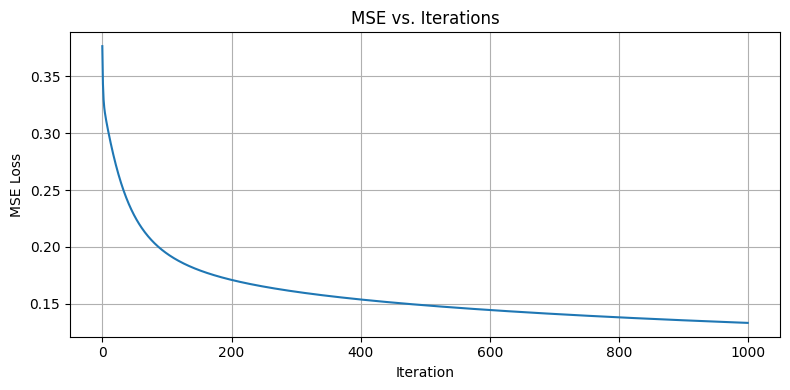

Confusion matrix (train):
[[30  0  0]
 [ 0 23  7]
 [ 0  0 30]]

Confusion matrix (test):
[[20  0  0]
 [ 0 17  3]
 [ 0  0 20]]

Training error rate: 0.0778
Test error rate: 0.0500


In [11]:
W_2 = train_linear_classifier(X2_train, y2_train, alpha=0.1, iterations=1000)

y2_pred_train = predict(X2_train, W_2)
y2_pred_test = predict(X2_test, W_2)

cm_train_2 =confusion_matrix(y_true = y2_train, y_pred = y2_pred_train)
cm_test_2 = confusion_matrix(y_true = y2_test, y_pred = y2_pred_test)

print("Confusion matrix (train):")
print(cm_train_2) 

print("\nConfusion matrix (test):")
print(cm_test_2)

train_error_2 = 1 - accuracy_score(y2_train, y2_pred_train)
test_error_2 = 1 - accuracy_score(y2_test, y2_pred_test)

print(f"\nTraining error rate: {train_error_2:.4f}")
print(f"Test error rate: {test_error_2:.4f}")


In [12]:
diff_train = train_error - train_error_2
diff_test = test_error - test_error_2

if test_error > test_error_2:
    print("\nCase 2 generalizes better (lower test error).")
elif test_error < test_error_2:
    print("\nCase 1 generalizes better (lower test error).")
else:
    print("\nBoth cases generalize equally well.")


print("\nDifferences abs((Case 1 - Case 2)):")
print(f"Train error difference: {abs(diff_train):.7f}")
print(f"Test error difference:  {abs(diff_test):.7f}")



Case 2 generalizes better (lower test error).

Differences abs((Case 1 - Case 2)):
Train error difference: 0.0000000
Test error difference:  0.0166667


In Case 1, where the model was trained on the first 30 samples per class, the training error was low, but the test error was higher than in Case 2.
In Case 2, using the last 30 samples per class for training, the model generalized slightly better, suggesting the later samples may better represent the test distribution.
The confusion matrices show that the model consistently confused class 1 and 2 more than class 0, possibly due to overlap in their features.
Overall, the choice of training samples affects generalization, and the model benefits from representative sampling.

# Task 2

The first 30 samples are used for training and the last 20 samples for testing. Producing histograms of each feature and class

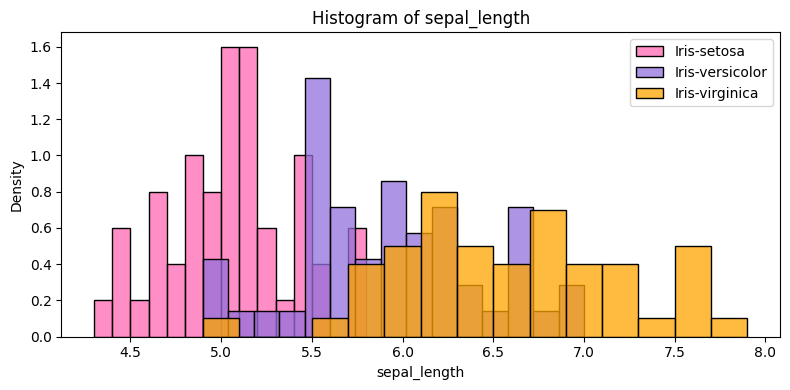

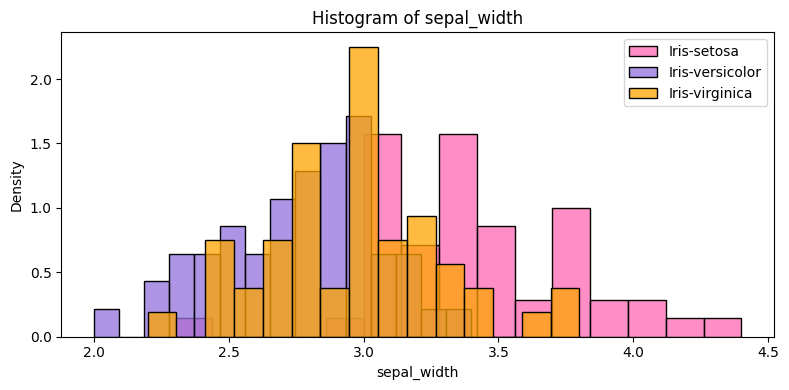

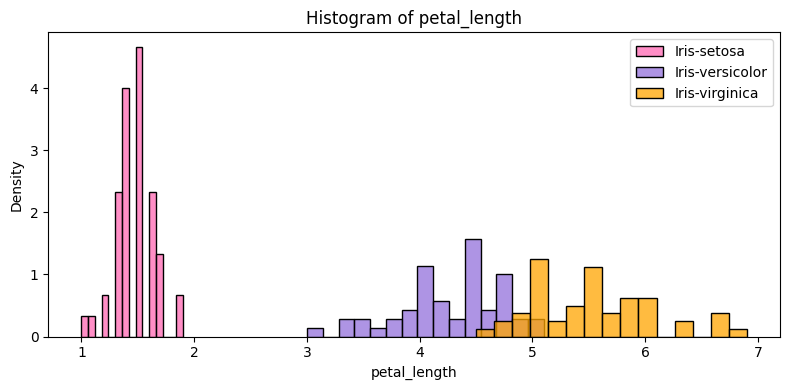

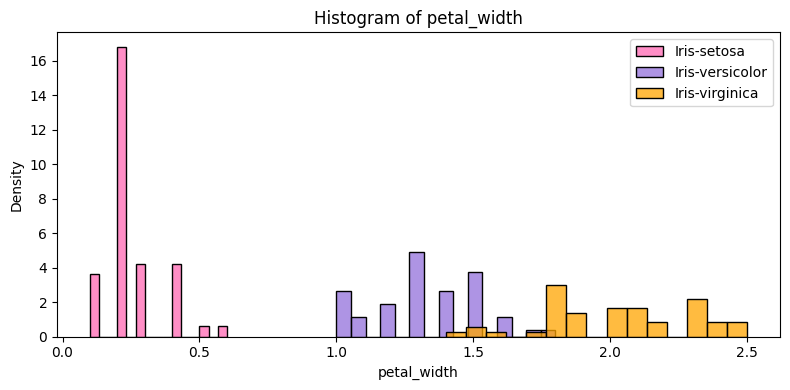

In [13]:
def print_histograms(df, features, class_col = "class"):
    class_colors = {
        'Iris-setosa': 'hotpink',
        'Iris-versicolor': 'mediumpurple',
        'Iris-virginica': 'orange'
    }
    features = col_names[:-1]
    for feature in features:
        plt.figure(figsize=(8,4))
        for label in sorted(df[class_col].unique()):
            sns.histplot(df[df[class_col] == label][feature], bins=15,color=class_colors.get(label, 'gray'), stat="density", label=label)
        plt.title(f'Histogram of {feature}')
        plt.xlabel(feature)
        plt.ylabel('Density')
        plt.legend()
        plt.tight_layout()
        plt.show()

print_histograms(df, col_names)


From histograms we see that sepal with is the feature that has the most overlapp. 

a) part-two: Now removing the most overlapping feature, and training the model on the reamining 3 features.

X_train: (90, 3) | Eksempel: [5.4 1.7 0.2]


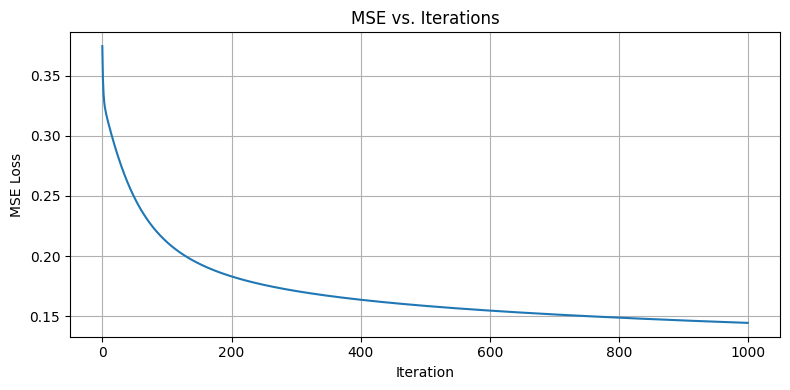

Confusion matrix (train):
[[30  0  0]
 [ 0 22  8]
 [ 0  0 30]]

Confusion matrix (test):
[[20  0  0]
 [ 0 13  7]
 [ 0  0 20]]

Training error rate: 0.0889
Test error rate: 0.1167

Case 2 generalizes better (lower test error).

Differences abs((Case 2 - Case 3)):
Train error difference: 0.0111111
Test error difference:  0.0666667


In [14]:
three_features = ['sepal_length', 'petal_length', 'petal_width', 'label']

X3_train, y3_train, X3_test, y3_test = splitData_2(df[three_features])
print("X_train:", X3_train.shape, "| Eksempel:", X3_train[0]) #check if the new X.shape is right ( only 3 features)

#training the new model
W3 = train_linear_classifier(X3_train, y3_train)
y3_pred_train = predict(X3_train, W3)
y3_pred_test = predict (X3_test, W3)


#creating the confusion matrix
cm3_train = confusion_matrix(y_true=y3_train , y_pred=y3_pred_train)
cm3_test = confusion_matrix(y_true=y3_test, y_pred=y3_pred_test)


print("Confusion matrix (train):")
print(cm3_train) 

print("\nConfusion matrix (test):")
print(cm3_test)

train_error_3 = 1 - accuracy_score(y3_train, y3_pred_train)
test_error_3 = 1 - accuracy_score(y3_test, y3_pred_test)

print(f"\nTraining error rate: {train_error_3:.4f}")
print(f"Test error rate: {test_error_3:.4f}")


#training error against model 2 with 4 features

diff_train_2 = train_error_2 - train_error_3
diff_test_2 = test_error_2 - test_error_3

if test_error_2 > test_error_3:
    print("\nCase 3 generalizes better (lower test error).")
elif test_error_2 < test_error_3:
    print("\nCase 2 generalizes better (lower test error).")
else:
    print("\nBoth cases generalize equally well.")

print("\nDifferences abs((Case 2 - Case 3)):")
print(f"Train error difference: {abs(diff_train_2):.7f}")
print(f"Test error difference:  {abs(diff_test_2):.7f}")


Repeat the experiment above with two and one features.

Experiment with 2 features:

X_train: (90, 2) | Eksempel: [1.7 0.2]


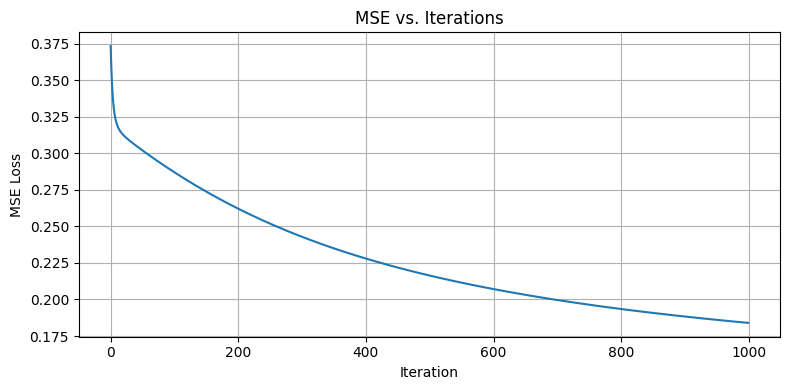

Confusion matrix (train):
[[30  0  0]
 [ 0  7 23]
 [ 0  0 30]]

Confusion matrix (test):
[[20  0  0]
 [ 0  5 15]
 [ 0  0 20]]

Training error rate: 0.2556
Test error rate: 0.2500

Case 2 generalizes better (lower test error).

Differences abs((Case 2 - Case 4)):
Train error difference: 0.1777778
Test error difference:  0.0666667


In [15]:
two_features = ['petal_length', 'petal_width', 'label']

X4_train, y4_train, X4_test, y4_test = splitData_2(df[two_features])
print("X_train:", X4_train.shape, "| Eksempel:", X4_train[0]) #check if the new X.shape is right ( only 3 features)

#training the new model
W4 = train_linear_classifier(X4_train, y4_train)
y4_pred_train = predict(X4_train, W4)
y4_pred_test = predict (X4_test, W4)


#creating the confusion matrix
cm4_train = confusion_matrix(y_true=y4_train , y_pred=y4_pred_train)
cm4_test = confusion_matrix(y_true=y4_test, y_pred=y4_pred_test)


print("Confusion matrix (train):")
print(cm4_train) 

print("\nConfusion matrix (test):")
print(cm4_test)

train_error_4 = 1 - accuracy_score(y4_train, y4_pred_train)
test_error_4 = 1 - accuracy_score(y4_test, y4_pred_test)

print(f"\nTraining error rate: {train_error_4:.4f}")
print(f"Test error rate: {test_error_4:.4f}")


#training error against model 2 with 4 features since it perofrmed best

diff_train_3 = train_error_2 - train_error_4
diff_test_3 = test_error_2 - test_error_3

if test_error_2 > test_error_4:
    print("\nCase 3 generalizes better (lower test error).")
elif test_error_2 < test_error_4:
    print("\nCase 2 generalizes better (lower test error).")
else:
    print("\nBoth cases generalize equally well.")

print("\nDifferences abs((Case 2 - Case 4)):")
print(f"Train error difference: {abs(diff_train_3):.7f}")
print(f"Test error difference:  {abs(diff_test_3):.7f}")


Experiment with 1 feature:

X_train: (90, 1) | Eksempel: [0.2]


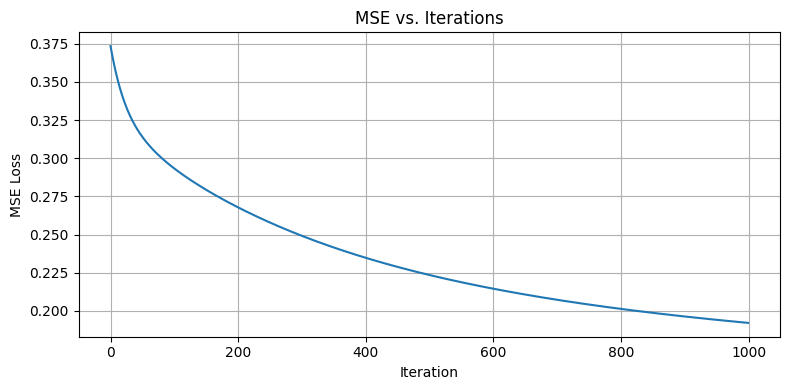

Confusion matrix (train):
[[30  0  0]
 [ 0  3 27]
 [ 0  0 30]]

Confusion matrix (test):
[[20  0  0]
 [ 0  4 16]
 [ 0  0 20]]

Training error rate: 0.3000
Test error rate: 0.2667

Case 2 generalizes better (lower test error).

Differences abs((Case 2 - Case 5)):
Train error difference: 0.2222222
Test error difference:  0.2166667


In [16]:
two_features = ['petal_width', 'label']

X5_train, y5_train, X5_test, y5_test = splitData_2(df[two_features])
print("X_train:", X5_train.shape, "| Eksempel:", X5_train[0]) #check if the new X.shape is right ( only 3 features)

#training the new model
W5 = train_linear_classifier(X5_train, y5_train)
y5_pred_train = predict(X5_train, W5)
y5_pred_test = predict (X5_test, W5)


#creating the confusion matrix
cm5_train = confusion_matrix(y_true=y5_train , y_pred=y5_pred_train)
cm5_test = confusion_matrix(y_true=y5_test, y_pred=y5_pred_test)


print("Confusion matrix (train):")
print(cm5_train) 

print("\nConfusion matrix (test):")
print(cm5_test)

train_error_5 = 1 - accuracy_score(y5_train, y5_pred_train)
test_error_5 = 1 - accuracy_score(y5_test, y5_pred_test)

print(f"\nTraining error rate: {train_error_5:.4f}")
print(f"Test error rate: {test_error_5:.4f}")


#training error against model 2 with 4 features since it perofrmed best

diff_train_4 = train_error_2 - train_error_5
diff_test_4 = test_error_2 - test_error_5

if test_error_2 > test_error_5:
    print("\nCase 3 generalizes better (lower test error).")
elif test_error_2 < test_error_5:
    print("\nCase 2 generalizes better (lower test error).")
else:
    print("\nBoth cases generalize equally well.")

print("\nDifferences abs((Case 2 - Case 5)):")
print(f"Train error difference: {abs(diff_train_4):.7f}")
print(f"Test error difference:  {abs(diff_test_4):.7f}")


### c) Comparison of Experiments

| Case  | Number of Features         | Training Error | Test Error |
|-------|----------------------------|----------------|------------|
| 1     | 4 (first 30 samples)       | 0.0778         | 0.0667     |
| 2     | 4 (last 30 samples)        | 0.0778         | **0.0500** |
| 3     | 3 features                 | 0.0889         | 0.1167     |
| 4     | 2 features                 | 0.2556         | 0.2500     |
| 5     | 1 feature                  | **0.3000**     | **0.2667** |

---

### Observations

- **Case 2** had the lowest test error, indicating that the last 30 samples are more representative of the test distribution, probably becasue the class 1 and 3 had closer representet values the model could train with.
- **Case 1 and 2** had identical training errors, but Case 2 generalized better.
- Reducing the number of features from 4 to 3 caused the test error to more than double, although the classifier still retained some predictive capability.
- With only 2 or 1 feature, both training and test errors increased significantly, especially for **class 1 (versicolor)**, which was frequently confused with **class 2 (virginica)**.
- **Class 0 (setosa)** was perfectly classified in all cases, suggesting strong linear separability regardless of feature subset, which can also be seen in teh histograms.

---

### Conclusion on Feature Properties

- **Petal length** and **petal width** contain the most discriminative information for linear classification.
- **Sepal features** contribute less and do not support good separation on their own.
- At least **three features** are needed to achieve acceptable accuracy for all three classes, especially to distinguish versicolor from virginica.
